In [1]:
data_dir = "../data/"


In [2]:
import os
import xarray as xr

sub_dir = os.path.join(data_dir, "train")
files = [os.path.join(sub_dir, f) for f in sorted(os.listdir(sub_dir)) if f.endswith(".nc")]
index = 0
file_path = files[index]
dataset = xr.load_dataset(file_path)
mask = dataset['LABELS'].values

In [3]:
from dataset.climatenet import ClimateDataset 
from torch.utils.data import DataLoader
from functools import partial
import random
import numpy as np
import torch

def worker_init_fn(worker_id: int, base_seed: int, same_worker_seed: bool = True):
    """
    Set random seed for each worker in DataLoader to ensure the reproducibility.

    """
    seed = base_seed if same_worker_seed else base_seed + worker_id

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    

val_dataset = ClimateDataset(
        data_dir=data_dir, train_flag=True, generate_prompt=True, augmented=True
    )
val_dataloader = DataLoader(
        dataset=val_dataset, batch_size=4, shuffle=False, num_workers=0,
        drop_last=False, collate_fn=val_dataset.collate_fn, worker_init_fn=partial(worker_init_fn, base_seed=3407)
    )


In [4]:
first_batch = next(iter(val_dataloader))
masks_batch = first_batch['gt_mask']
binary_mask = masks_batch[0].cpu().numpy()  


In [8]:
from model.prompt.prompt_maker import PromptMaker
prompt_maker = PromptMaker(prompt_type='point')

In [9]:
prompt_dict = prompt_maker.make_prompts(masks_batch)

In [16]:
prompt_dict['ar_point_prompts'][0][1]

tensor([[1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0.],
        [1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0.],
        [1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0.],
        [1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0.],
        [1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0.],
        [1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0.],
        [1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0.],
        [1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0.],
        [1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0.]])

In [16]:
import cv2
def make_bbox_prompts(binary_mask, connectivity, threshold=50):
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(binary_mask.astype(np.uint8), connectivity=connectivity)
    object_masks_list = []
    bboxes = []
    for obj_index in range(1, num_labels):  # skip background label 0
        stat = stats[obj_index]
        area_in_pixels = stat[4]
        if area_in_pixels >= threshold:
            left, top, width, height, _ = stat
            # Create binary mask for the current object
            object_mask = (labels == obj_index).astype(np.uint8)
            object_masks_list.append(object_mask)
            right = left + width - 1
            bottom = top + height - 1
            bounding_box = [left, top, right, bottom]
            bboxes.append([bounding_box])
    bboxes_prompts = torch.from_numpy(np.stack(bboxes, axis=0)).to(torch.float32)
    object_masks = torch.from_numpy(np.stack(object_masks_list, axis=0)).to(torch.float32).unsqueeze(1)
    return bboxes_prompts, object_masks


In [ ]:
def make_point_prompts(binary_mask, connectivity, threshold=50, num_positive_points=5, num_negative_points=5):
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(binary_mask.astype(np.uint8), connectivity=connectivity)
    object_masks_list = []
    positive_points_list = []
    negative_points_list = []
    for obj_index in range(1, num_labels):
        stat = stats[obj_index]
        area_in_pixels = stat[4]
        if area_in_pixels >= threshold:
            object_mask = (labels == obj_index).astype(np.uint8)
            object_masks_list.append(object_mask)
            object_centroid = centroids[obj_index]
            #POSITIVE POINTS
            positive_points = make_positive_point_prompts(object_mask=object_mask, object_centroid=object_centroid, num_points=num_positive_points)
            positive_points_list.append(positive_points)
            #NEGATIVE POINTS
            negative_points = make_negative_point_prompts(object_mask=object_mask, object_centroid=object_centroid, num_points=num_negative_points)
            negative_points_list.append(negative_points)
            
    object_masks = torch.from_numpy(np.stack(object_masks_list, axis=0)).to(torch.float32).unsqueeze(1)
    
    
    # point_list = np.stack([positive_points_list, negative_points_list], axis=1)
    positive_point_coords = torch.from_numpy(np.stack(positive_points_list, axis=0)).to(torch.float32)
    negative_point_coords = torch.from_numpy(np.stack(negative_points_list, axis=0)).to(torch.float32)
    
    point_coords = torch.cat([positive_point_coords, negative_point_coords], dim=1)
    positive_point_labels = torch.ones(positive_point_coords.shape[:-1], dtype=torch.float32)
    negative_point_labels = torch.zeros(negative_point_coords.shape[:-1], dtype=torch.float32)
    
    point_labels = torch.cat([positive_point_labels, negative_point_labels], dim=1)
    point_prompts = (point_coords, point_labels)
    
    return point_prompts, object_masks
            
            
def make_negative_point_prompts(object_mask, object_centroid, num_points=5):
    #dilate it
    
    dilated_mask_small = cv2.dilate(object_mask.astype(np.uint8), kernel=np.ones((10,10), np.uint8), iterations=3)
    dilated_mask_big = cv2.dilate(object_mask.astype(np.uint8), kernel=np.ones((25,25), np.uint8), iterations=3)
    negative_region = dilated_mask_big - dilated_mask_small
    region_points = np.argwhere(negative_region)
    selected_indices = np.random.choice(len(region_points), size=num_points, replace=False)
    negative_points = region_points[selected_indices]
    negative_points = [pt[::-1] for pt in negative_points]
    # import matplotlib.pyplot as plt

    # # visualize object mask, dilated mask and negative region side-by-side
    # fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    # axes[0].imshow(object_mask, cmap='gray')
    # axes[0].set_title('Object Mask')
    # axes[0].axis('off')

    # axes[1].imshow(dilated_mask_big, cmap='gray')
    # axes[1].set_title('Dilated Mask')
    # axes[1].axis('off')

    # axes[2].imshow(negative_region, cmap='gray')
    # axes[2].set_title('Negative Region')
    # axes[2].axis('off')

    # plt.tight_layout()
    # plt.show()
    return negative_points
    
    
def make_positive_point_prompts(object_mask, object_centroid, num_points=5):
    object_points = np.argwhere(object_mask)
    selected_indices = np.random.choice(len(object_points), size=num_points, replace=False)
    positive_points = object_points[selected_indices]
    positive_points = [pt[::-1] for pt in positive_points]
    positive_points.append(object_centroid)
    return positive_points

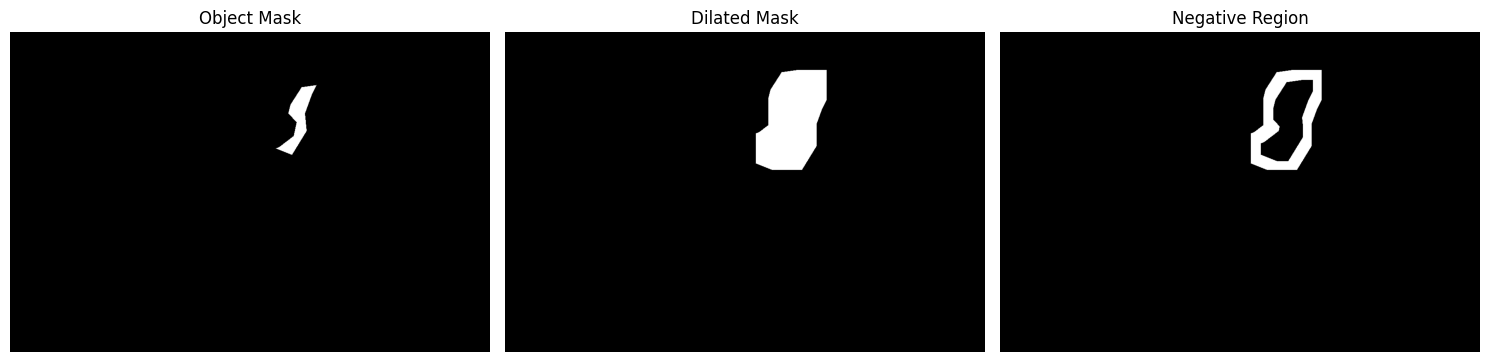

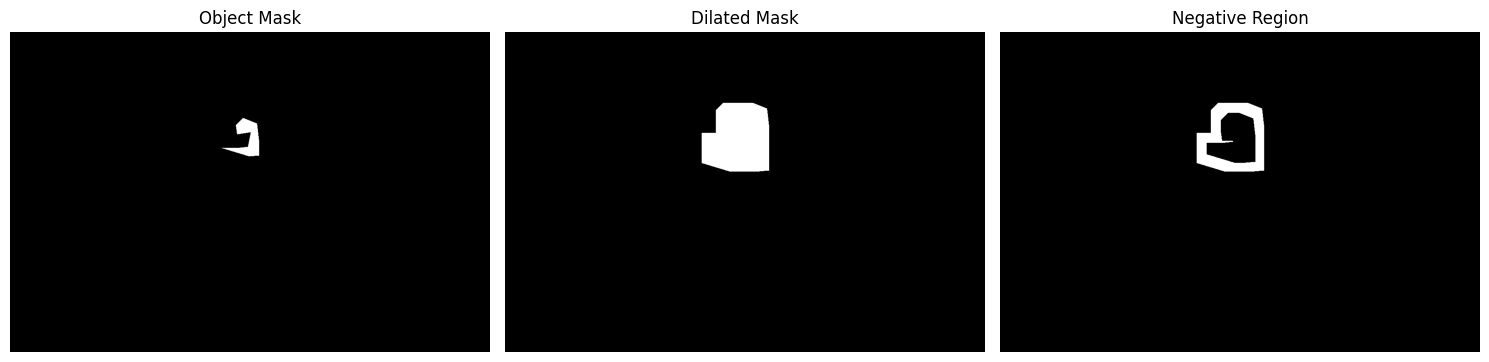

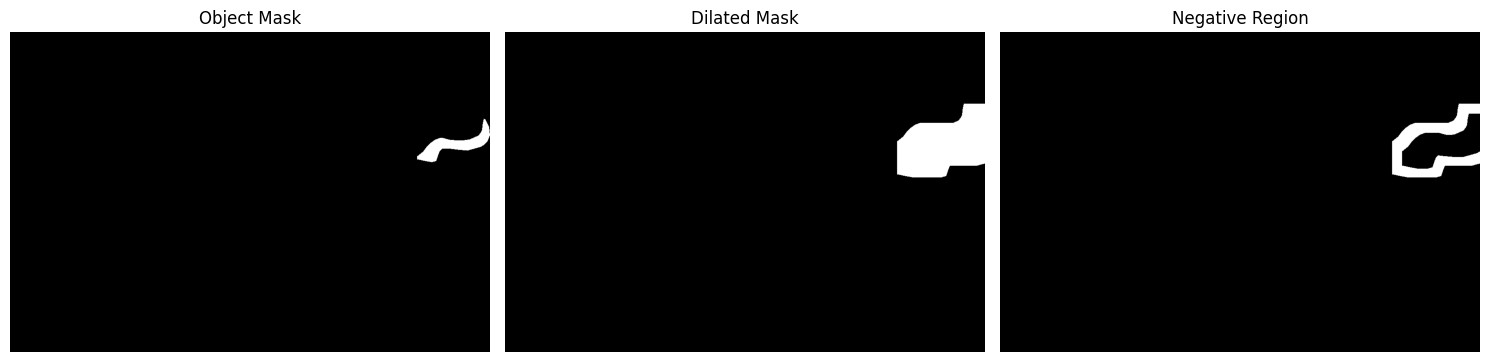

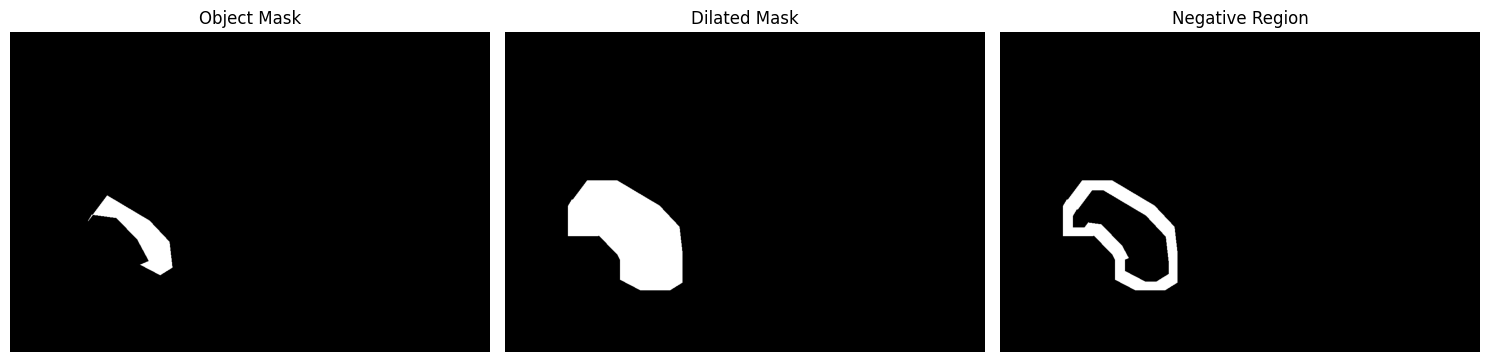

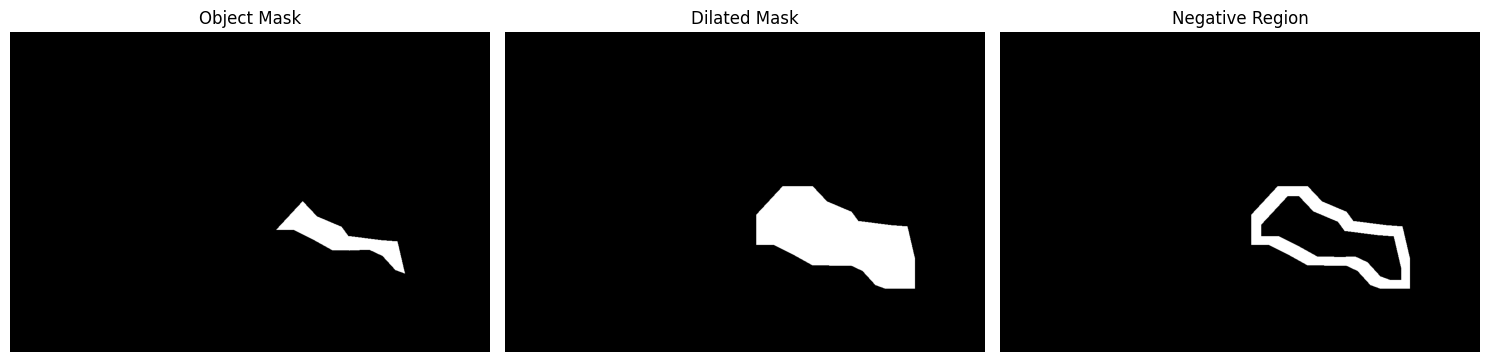

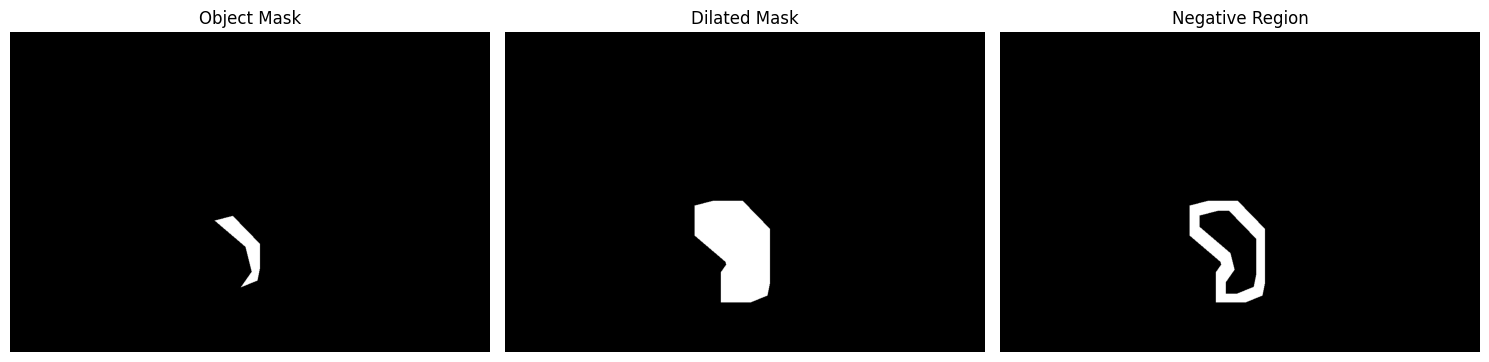

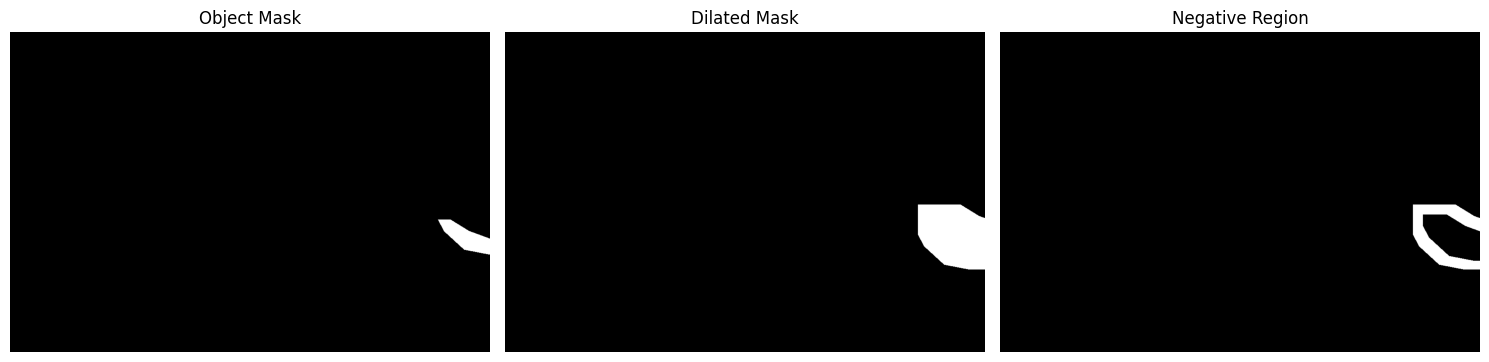

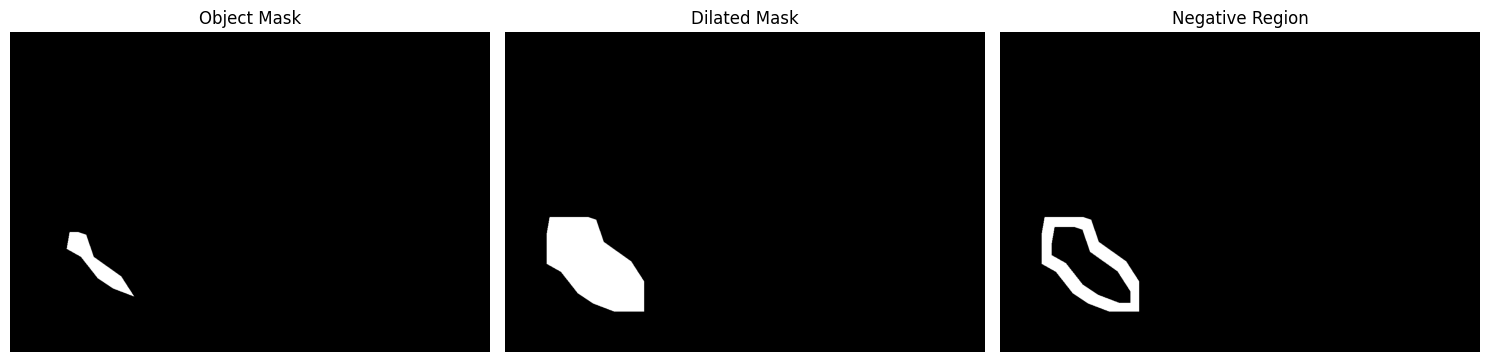

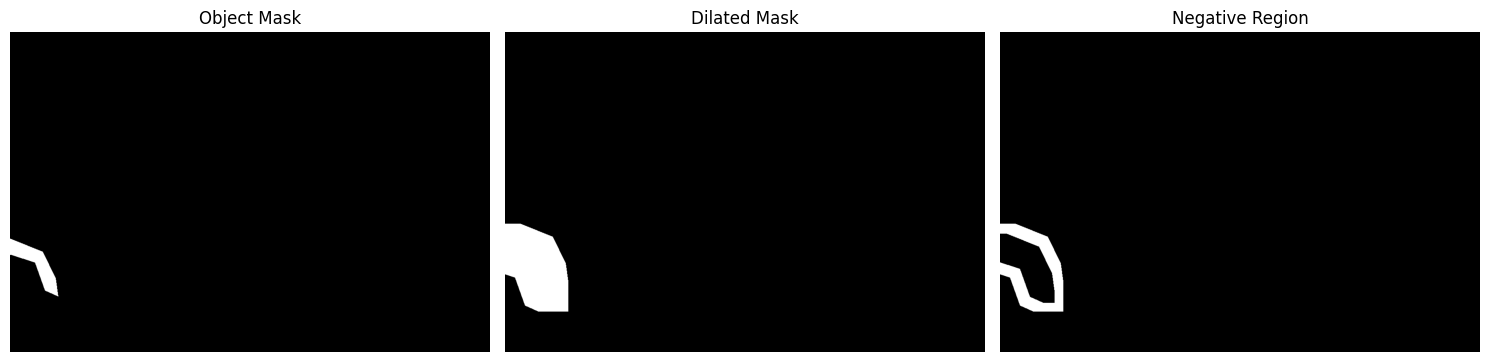

In [73]:
import cv2
connectivity = 8
prompt_type = 'point'
threshold=50


ar_mask = binary_mask == 2
bbox_prompts, _ = make_bbox_prompts(ar_mask, connectivity, threshold)
point_prompt, _ = make_point_prompts(ar_mask, connectivity, threshold, num_positive_points=5, num_negative_points=5)

        

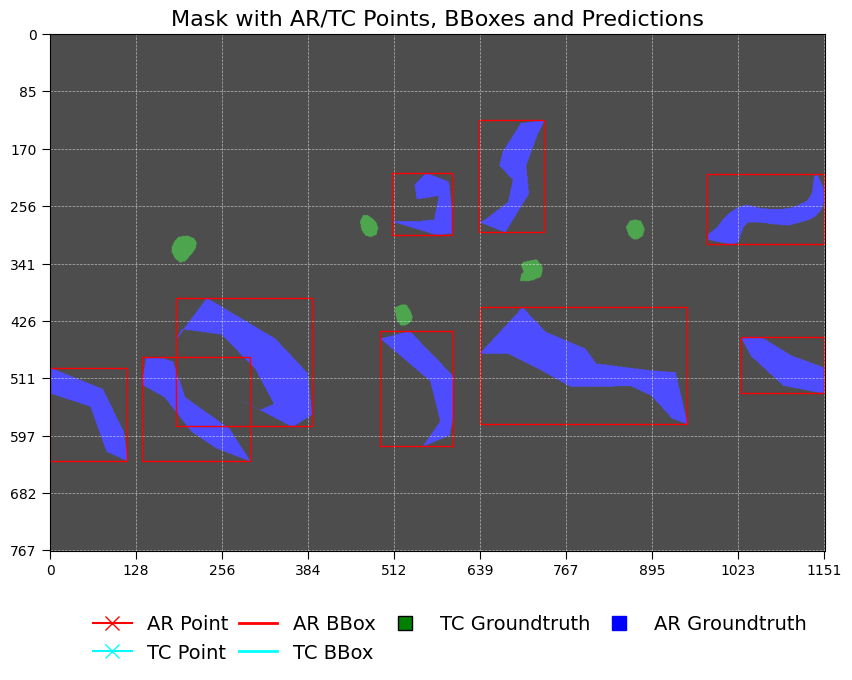

In [19]:
from train_util import plot_mask_with_points_and_bbox
fig = plot_mask_with_points_and_bbox(binary_mask, None, None, bbox_prompts, None, None, None, radius=8, save_path=f'exp/debug/val_step_{1}.png', axis =True)
fig